In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# Load the features you saved in Phase 1
df = pd.read_csv('data/features.csv', index_col=0, parse_dates=True)

print(f"Loaded {len(df)} rows")
print(f"Date range: {df.index.min()} to {df.index.max()}")
print(f"Tickers: {df['ticker'].unique()}")
print(f"\nTarget distribution:")
print(df['target'].value_counts(normalize=True).round(3))

Loaded 6045 rows
Date range: 2019-03-14 00:00:00 to 2023-12-29 00:00:00
Tickers: <StringArray>
['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'JPM']
Length: 5, dtype: str

Target distribution:
target
1    0.567
0    0.433
Name: proportion, dtype: float64


In [2]:
# These are the columns your model will learn from
# We exclude raw price columns — the model should learn from 
# derived features, not raw prices which vary hugely between stocks
feature_cols = [
    'return_1d', 'return_5d', 'return_20d',
    'price_to_sma20', 'price_to_sma50', 'sma_cross',
    'rsi_14',
    'macd', 'macd_signal', 'macd_hist',
    'bb_position', 'bb_width',
    'volume_ratio'
]

X = df[feature_cols]
y = df['target']

# Walk-forward split — everything before 2023 is training, 2023 onward is test
split_date = '2023-01-01'

X_train = X[X.index < split_date]
X_test  = X[X.index >= split_date]
y_train = y[y.index < split_date]
y_test  = y[y.index >= split_date]

print(f"Training set: {len(X_train)} rows ({X_train.index.min().date()} to {X_train.index.max().date()})")
print(f"Test set:     {len(X_test)} rows ({X_test.index.min().date()} to {X_test.index.max().date()})")
print(f"\nTraining target distribution:")
print(y_train.value_counts(normalize=True).round(3))
print(f"\nTest target distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training set: 4795 rows (2019-03-14 to 2022-12-30)
Test set:     1250 rows (2023-01-03 to 2023-12-29)

Training target distribution:
target
1    0.555
0    0.445
Name: proportion, dtype: float64

Test target distribution:
target
1    0.614
0    0.386
Name: proportion, dtype: float64


In [3]:
# Scaling transforms all features to the same range
# Why does this matter? Logistic Regression is sensitive to scale —
# a feature ranging from 0-100 (like RSI) would dominate a feature 
# ranging from 0-0.01 (like daily returns) without scaling.
# Tree-based models (Random Forest, XGBoost) don't need scaling,
# but it doesn't hurt them either — so we scale everything for consistency.

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)    # learn the scale FROM training data
X_test_scaled  = scaler.transform(X_test)          # apply SAME scale to test data

# Critical rule: never fit the scaler on test data — that would be 
# another form of data leakage (your scaler would "know" future statistics)

print("Scaling complete")
print(f"Feature means (should be ~0 after scaling): {X_train_scaled.mean(axis=0).round(2)}")

Scaling complete
Feature means (should be ~0 after scaling): [-0. -0. -0. -0.  0. -0. -0.  0. -0. -0. -0.  0. -0.]


In [4]:
# Model 1: Logistic Regression
# The simplest model — draws a straight line to separate ups from downs
# Good baseline to beat
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
print("✓ Logistic Regression trained")

# Model 2: Random Forest
# Builds hundreds of decision trees and combines their votes
# Each tree learns slightly different patterns — together they're more robust
# n_estimators=200 means 200 trees
rf_model = RandomForestClassifier(n_estimators=200, max_depth=5, 
                                   random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)
print("✓ Random Forest trained")

# Model 3: XGBoost
# Builds trees sequentially — each tree learns from the mistakes of the previous one
# Usually the strongest performer on tabular data
# This is the model that wins most Kaggle competitions
xgb_model = xgb.XGBClassifier(n_estimators=200, max_depth=4, 
                                learning_rate=0.05, random_state=42,
                                eval_metric='logloss', verbosity=0)
xgb_model.fit(X_train_scaled, y_train)
print("✓ XGBoost trained")

✓ Logistic Regression trained
✓ Random Forest trained
✓ XGBoost trained


In [5]:
def evaluate_model(name, model, X_test_scaled, y_test):
    # Get predictions
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]  # probability of going UP
    
    # Calculate metrics
    auc   = roc_auc_score(y_test, y_prob)
    report = classification_report(y_test, y_pred, output_dict=True)
    
    precision = report['1']['precision']
    recall    = report['1']['recall']
    f1        = report['1']['f1-score']
    accuracy  = report['accuracy']
    
    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(f"  Accuracy  : {accuracy:.3f}")
    print(f"  AUC       : {auc:.3f}  ← most important metric")
    print(f"  Precision : {precision:.3f}")
    print(f"  Recall    : {recall:.3f}")
    print(f"  F1 Score  : {f1:.3f}")
    
    return {'name': name, 'auc': auc, 'accuracy': accuracy, 
            'f1': f1, 'y_pred': y_pred, 'y_prob': y_prob}

# Evaluate all three
lr_results  = evaluate_model("Logistic Regression", lr_model, X_test_scaled, y_test)
rf_results  = evaluate_model("Random Forest",       rf_model, X_test_scaled, y_test)
xgb_results = evaluate_model("XGBoost",             xgb_model, X_test_scaled, y_test)


  Logistic Regression
  Accuracy  : 0.594
  AUC       : 0.492  ← most important metric
  Precision : 0.615
  Recall    : 0.905
  F1 Score  : 0.732

  Random Forest
  Accuracy  : 0.597
  AUC       : 0.459  ← most important metric
  Precision : 0.623
  Recall    : 0.866
  F1 Score  : 0.725

  XGBoost
  Accuracy  : 0.521
  AUC       : 0.463  ← most important metric
  Precision : 0.605
  Recall    : 0.631
  F1 Score  : 0.618


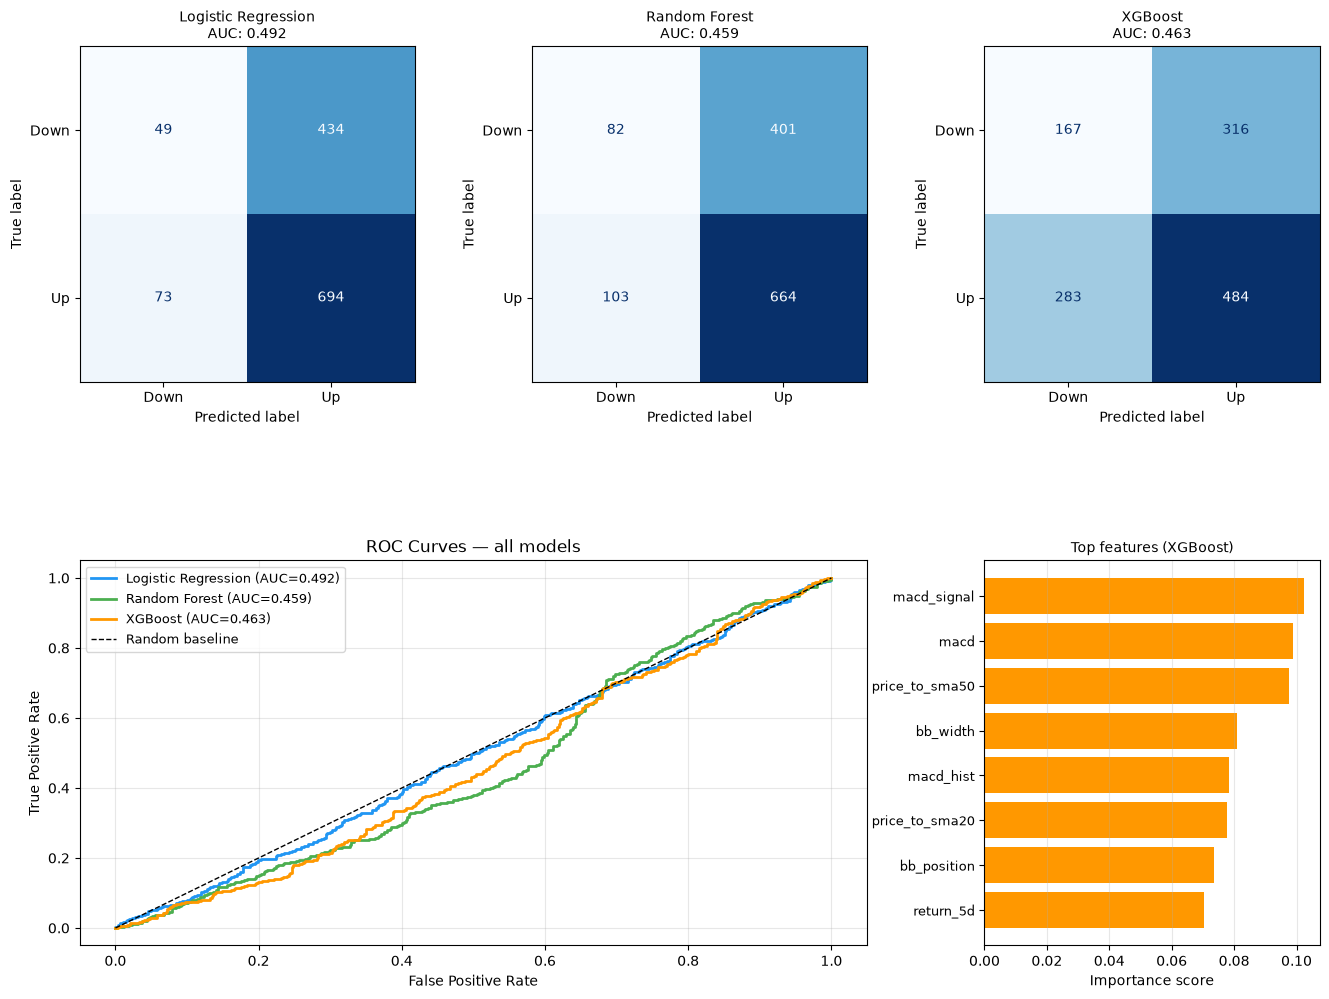

Chart saved as model_evaluation.png


In [6]:
fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(2, 3, hspace=0.4, wspace=0.35)

results = [lr_results, rf_results, xgb_results]
colors  = ['#2196F3', '#4CAF50', '#FF9800']

# --- Row 1: Confusion matrices for each model ---
for i, (res, color) in enumerate(zip(results, colors)):
    ax = fig.add_subplot(gs[0, i])
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Down', 'Up'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{res['name']}\nAUC: {res['auc']:.3f}", fontsize=10)

# --- Row 2: ROC curves for all models on one chart ---
ax_roc = fig.add_subplot(gs[1, 0:2])
for res, color in zip(results, colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax_roc.plot(fpr, tpr, color=color, linewidth=2, 
                label=f"{res['name']} (AUC={res['auc']:.3f})")
ax_roc.plot([0,1], [0,1], 'k--', linewidth=1, label='Random baseline')
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.set_title('ROC Curves — all models')
ax_roc.legend(fontsize=9)
ax_roc.grid(True, alpha=0.3)

# --- Row 2: Feature importance from XGBoost ---
ax_feat = fig.add_subplot(gs[1, 2])
importances = xgb_model.feature_importances_
indices = np.argsort(importances)[::-1]
top_n = 8

ax_feat.barh(range(top_n), importances[indices[:top_n]][::-1], color='#FF9800')
ax_feat.set_yticks(range(top_n))
ax_feat.set_yticklabels([feature_cols[i] for i in indices[:top_n]][::-1], fontsize=9)
ax_feat.set_title('Top features (XGBoost)', fontsize=10)
ax_feat.set_xlabel('Importance score')
ax_feat.grid(True, alpha=0.3, axis='x')

plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as model_evaluation.png")

In [7]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

# TimeSeriesSplit is the walk-forward version of cross-validation
# It creates multiple train/test splits that always respect time order:
# Split 1: train on chunk 1, test on chunk 2
# Split 2: train on chunks 1-2, test on chunk 3
# Split 3: train on chunks 1-3, test on chunk 4
# This gives a much more honest estimate of real performance

tscv = TimeSeriesSplit(n_splits=5)

# Parameter grid — these are the knobs we're turning
param_grid = {
    'n_estimators':  [100, 200, 300],
    'max_depth':     [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample':     [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

xgb_base = xgb.XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0)

# RandomizedSearchCV tries 30 random combinations instead of all possible ones
# This saves time while still finding good settings
search = RandomizedSearchCV(
    xgb_base, param_grid,
    n_iter=30,
    scoring='roc_auc',
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train_scaled, y_train)

print(f"\nBest parameters found:")
for param, value in search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nBest cross-validated AUC: {search.best_score_:.3f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best parameters found:
  subsample: 0.7
  n_estimators: 200
  max_depth: 3
  learning_rate: 0.01
  colsample_bytree: 1.0

Best cross-validated AUC: 0.540


In [8]:
# Evaluate the tuned model on the test set
best_xgb = search.best_estimator_

y_pred_tuned = best_xgb.predict(X_test_scaled)
y_prob_tuned = best_xgb.predict_proba(X_test_scaled)[:, 1]
auc_tuned    = roc_auc_score(y_test, y_prob_tuned)

print(f"Tuned XGBoost AUC: {auc_tuned:.3f}")
print(f"Original XGBoost AUC: {xgb_results['auc']:.3f}")
print(f"Improvement: {(auc_tuned - xgb_results['auc']):.3f}")
print(f"\nDetailed report:")
print(classification_report(y_test, y_pred_tuned, target_names=['Down', 'Up']))

Tuned XGBoost AUC: 0.463
Original XGBoost AUC: 0.463
Improvement: 0.000

Detailed report:
              precision    recall  f1-score   support

        Down       0.46      0.20      0.28       483
          Up       0.63      0.85      0.72       767

    accuracy                           0.60      1250
   macro avg       0.55      0.53      0.50      1250
weighted avg       0.56      0.60      0.55      1250



In [9]:
import pickle
import os

os.makedirs('models', exist_ok=True)

# Save the tuned model and scaler
# You'll need both in Phase 4 when you build the API
with open('models/best_xgb_model.pkl', 'wb') as f:
    pickle.dump(best_xgb, f)

with open('models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save the feature column names too — critical for the API later
with open('models/feature_cols.pkl', 'wb') as f:
    pickle.dump(feature_cols, f)

print("Saved:")
print("  models/best_xgb_model.pkl")
print("  models/scaler.pkl")
print("  models/feature_cols.pkl")

Saved:
  models/best_xgb_model.pkl
  models/scaler.pkl
  models/feature_cols.pkl


In [10]:
# Step 1 — Add lag features to capture patterns over time
# Instead of just "what is RSI today", give the model:
# "what was RSI today, yesterday, and 2 days ago"
# This lets it learn sequences like "RSI dropped 3 days in a row"

def add_lag_features(df, feature_cols, lags=[1, 2, 3]):
    df = df.copy()
    new_cols = []
    
    for col in ['rsi_14', 'macd_hist', 'bb_position', 'return_1d', 'volume_ratio']:
        for lag in lags:
            new_col = f'{col}_lag{lag}'
            df[new_col] = df[col].shift(lag)
            new_cols.append(new_col)
    
    return df, new_cols

# Reload the original data and rebuild with lag features
df_enhanced = pd.read_csv('data/features.csv', index_col=0, parse_dates=True)
df_enhanced, lag_cols = add_lag_features(df_enhanced, feature_cols)
df_enhanced.dropna(inplace=True)

print(f"Added {len(lag_cols)} lag features")
print(f"New lag columns: {lag_cols}")

Added 15 lag features
New lag columns: ['rsi_14_lag1', 'rsi_14_lag2', 'rsi_14_lag3', 'macd_hist_lag1', 'macd_hist_lag2', 'macd_hist_lag3', 'bb_position_lag1', 'bb_position_lag2', 'bb_position_lag3', 'return_1d_lag1', 'return_1d_lag2', 'return_1d_lag3', 'volume_ratio_lag1', 'volume_ratio_lag2', 'volume_ratio_lag3']


In [11]:
# Step 2 — Rebuild train/test split with enhanced features
enhanced_feature_cols = feature_cols + lag_cols

X_enhanced = df_enhanced[enhanced_feature_cols]
y_enhanced = df_enhanced['target']

split_date = '2023-01-01'
X_train_e = X_enhanced[X_enhanced.index < split_date]
X_test_e  = X_enhanced[X_enhanced.index >= split_date]
y_train_e = y_enhanced[y_enhanced.index < split_date]
y_test_e  = y_enhanced[y_enhanced.index >= split_date]

# Scale
scaler_e = StandardScaler()
X_train_e_scaled = scaler_e.fit_transform(X_train_e)
X_test_e_scaled  = scaler_e.transform(X_test_e)

print(f"Enhanced feature count: {len(enhanced_feature_cols)}")
print(f"Train rows: {len(X_train_e)}, Test rows: {len(X_test_e)}")

Enhanced feature count: 28
Train rows: 4792, Test rows: 1250


In [12]:
# Step 3 — Retrain XGBoost with class balancing
# scale_pos_weight tells XGBoost to penalize missing "Down" predictions more heavily
# The value is calculated as: number of Down examples / number of Up examples

down_count = (y_train_e == 0).sum()
up_count   = (y_train_e == 1).sum()
balance_ratio = down_count / up_count

print(f"Down: {down_count}, Up: {up_count}, Ratio: {balance_ratio:.2f}")

xgb_balanced = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=balance_ratio,   # ← this is the class balancing fix
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

xgb_balanced.fit(X_train_e_scaled, y_train_e)

y_pred_bal = xgb_balanced.predict(X_test_e_scaled)
y_prob_bal = xgb_balanced.predict_proba(X_test_e_scaled)[:, 1]
auc_bal    = roc_auc_score(y_test_e, y_prob_bal)

print(f"\nBalanced XGBoost AUC: {auc_bal:.3f}")
print(f"\nDetailed report:")
print(classification_report(y_test_e, y_pred_bal, target_names=['Down', 'Up']))

Down: 2134, Up: 2658, Ratio: 0.80

Balanced XGBoost AUC: 0.453

Detailed report:
              precision    recall  f1-score   support

        Down       0.35      0.50      0.41       483
          Up       0.57      0.42      0.49       767

    accuracy                           0.45      1250
   macro avg       0.46      0.46      0.45      1250
weighted avg       0.49      0.45      0.46      1250



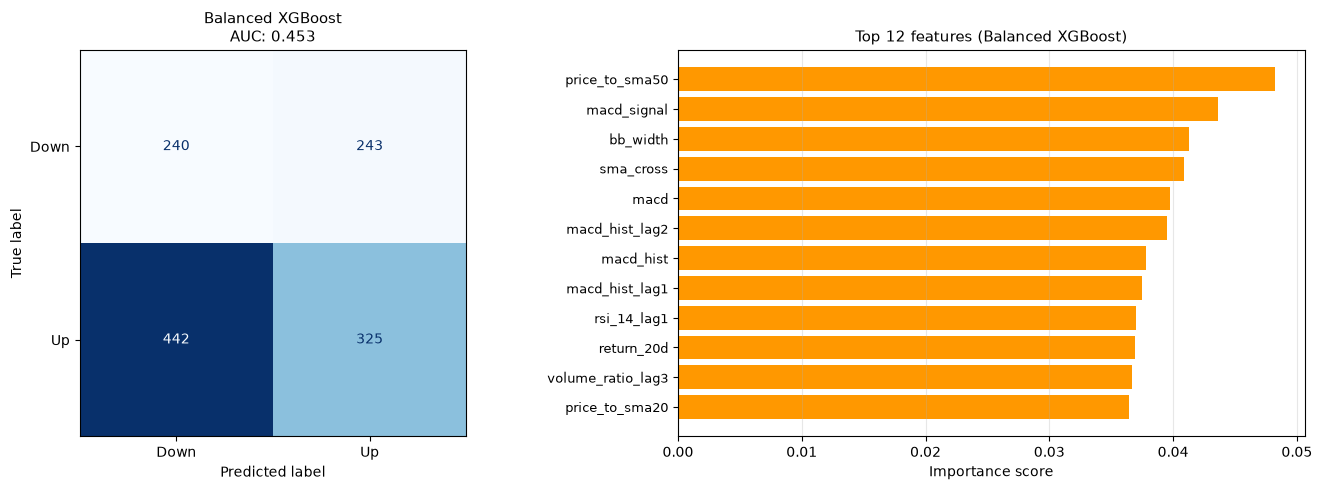


Summary of improvements:
  Original XGBoost AUC:  0.463
  Balanced XGBoost AUC:  0.453


In [13]:
# Step 4 — Visualize improved feature importances
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_test_e, y_pred_bal)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Down', 'Up'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Balanced XGBoost\nAUC: {auc_bal:.3f}', fontsize=11)

# Feature importance — top 12
importances = xgb_balanced.feature_importances_
indices = np.argsort(importances)[::-1]
top_n = 12

axes[1].barh(range(top_n), importances[indices[:top_n]][::-1], color='#FF9800')
axes[1].set_yticks(range(top_n))
axes[1].set_yticklabels([enhanced_feature_cols[i] for i in indices[:top_n]][::-1], fontsize=9)
axes[1].set_title('Top 12 features (Balanced XGBoost)', fontsize=11)
axes[1].set_xlabel('Importance score')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('balanced_model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSummary of improvements:")
print(f"  Original XGBoost AUC:  {xgb_results['auc']:.3f}")
print(f"  Balanced XGBoost AUC:  {auc_bal:.3f}")

In [14]:
# Save the improved model
with open('models/best_xgb_model.pkl', 'wb') as f:
    pickle.dump(xgb_balanced, f)

with open('models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler_e, f)

with open('models/feature_cols.pkl', 'wb') as f:
    pickle.dump(enhanced_feature_cols, f)

print("Updated models saved successfully")

Updated models saved successfully
